In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
N_SEGS = 6  # must match --n-segs used to build the brute-force LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780     # fixed: not searched
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    h_stack, idx_ok = [], []
    for i in range(params.shape[0]):
        (logm1, logm2, a_i, p0_i, e0_i, dist_i,
         cos_qS_i, phiS_i, cos_qK_i, phiK_i, Phi_phi0_i, Phi_r0_i) = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            qK_i = np.arccos(cos_qK_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist_i, qS_i, phiS_i, qK_i, phiK_i,
                Phi_phi0_i, Phi_theta0, Phi_r0_i,
                T=T, dt=dt,
            ))
            h_stack.append(h_temp)
            idx_ok.append(i)
        except Exception:
            pass
    if h_stack:
        h_batch = gwf.xp.stack(h_stack, axis=0)  # (b, n_chan, N)
        snr = gwf.SNR_semicoherent_batch(loglike_obj.signal, h_batch, N_seg=N_SEGS, phase_max=True)
        for k, i in enumerate(idx_ok):
            out[i] = float(snr[k])
    return out


# Broad priors — same bounds as run_lhs_noise_sc_brute.py. xI0 (only 1.0 is
# valid for the waveform model) and Phi_theta0 are held fixed (not
# searched); sky/spin polar angles sampled uniform in cosine.
LOGM1_LIM = [5.81854, 5.83713]
LOGM2_LIM = [1.99115, 1.99507]
A_LIM     = [0.49296, 0.51048]
P0_LIM    = [15.53112, 15.88282]
E0_LIM    = [0.74301, 0.74536]
DIST_LIM  = [3,  5]
COSQS_LIM = [-1.0, 1.0]
PHIS_LIM  = [0.0,  2 * np.pi]
COSQK_LIM = [-1.0, 1.0]
PHIK_LIM  = [0.0,  2 * np.pi]
PHIPHI0_LIM = [0.0, 2 * np.pi]
PHIR0_LIM   = [0.0, 2 * np.pi]


def prior_transform(u):
    t = np.zeros_like(u)
    t[:, 0]  = (LOGM1_LIM[1] - LOGM1_LIM[0]) * u[:, 0] + LOGM1_LIM[0]
    t[:, 1]  = (LOGM2_LIM[1] - LOGM2_LIM[0]) * u[:, 1] + LOGM2_LIM[0]
    t[:, 2]  = (A_LIM[1] - A_LIM[0]) * u[:, 2] + A_LIM[0]
    t[:, 3]  = (P0_LIM[1] - P0_LIM[0]) * u[:, 3] + P0_LIM[0]
    t[:, 4]  = (E0_LIM[1] - E0_LIM[0]) * u[:, 4] + E0_LIM[0]
    t[:, 5]  = (DIST_LIM[1] - DIST_LIM[0]) * u[:, 5] + DIST_LIM[0]
    t[:, 6]  = (COSQS_LIM[1] - COSQS_LIM[0]) * u[:, 6] + COSQS_LIM[0]
    t[:, 7]  = (PHIS_LIM[1] - PHIS_LIM[0]) * u[:, 7] + PHIS_LIM[0]
    t[:, 8]  = (COSQK_LIM[1] - COSQK_LIM[0]) * u[:, 8] + COSQK_LIM[0]
    t[:, 9]  = (PHIK_LIM[1] - PHIK_LIM[0]) * u[:, 9] + PHIK_LIM[0]
    t[:, 10] = (PHIPHI0_LIM[1] - PHIPHI0_LIM[0]) * u[:, 10] + PHIPHI0_LIM[0]
    t[:, 11] = (PHIR0_LIM[1] - PHIR0_LIM[0]) * u[:, 11] + PHIR0_LIM[0]
    return t


def inverse_prior_transform(params):
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0]  = (params[:, 0] - LOGM1_LIM[0]) / (LOGM1_LIM[1] - LOGM1_LIM[0])
    u[:, 1]  = (params[:, 1] - LOGM2_LIM[0]) / (LOGM2_LIM[1] - LOGM2_LIM[0])
    u[:, 2]  = (params[:, 2] - A_LIM[0]) / (A_LIM[1] - A_LIM[0])
    u[:, 3]  = (params[:, 3] - P0_LIM[0]) / (P0_LIM[1] - P0_LIM[0])
    u[:, 4]  = (params[:, 4] - E0_LIM[0]) / (E0_LIM[1] - E0_LIM[0])
    u[:, 5]  = (params[:, 5] - DIST_LIM[0]) / (DIST_LIM[1] - DIST_LIM[0])
    u[:, 6]  = (params[:, 6] - COSQS_LIM[0]) / (COSQS_LIM[1] - COSQS_LIM[0])
    u[:, 7]  = (params[:, 7] - PHIS_LIM[0]) / (PHIS_LIM[1] - PHIS_LIM[0])
    u[:, 8]  = (params[:, 8] - COSQK_LIM[0]) / (COSQK_LIM[1] - COSQK_LIM[0])
    u[:, 9]  = (params[:, 9] - PHIK_LIM[0]) / (PHIK_LIM[1] - PHIK_LIM[0])
    u[:, 10] = (params[:, 10] - PHIPHI0_LIM[0]) / (PHIPHI0_LIM[1] - PHIPHI0_LIM[0])
    u[:, 11] = (params[:, 11] - PHIR0_LIM[0]) / (PHIR0_LIM[1] - PHIR0_LIM[0])
    return u


Using dt=5s, T=1.0yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage2_merge_brute/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [ ]:
len(sampler.now_covariances)

10

In [5]:
n = sampler.element_num_list  # filled length per proc, e.g. [37001]*10

proc_pt      = [sampler.searched_points_list[i][:n[i]]        for i in range(sampler.n_proc)]
logden_list  = [sampler.searched_log_densities_list[i][:n[i]] for i in range(sampler.n_proc)]

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.82823584,  1.99321534,  0.50249727, 15.68750185,  0.74337348,
         4.34912446,  0.82592136,  3.60967665,  0.69796553,  3.09941436,
         3.40361281,  4.7843498 ]])

In [7]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 5.82576191,  1.99218474,  0.49598774, 15.73294237,  0.74424825,
         3.15855255,  0.77190326,  3.64814537,  0.82344278,  3.78480913,
         4.41118045,  5.86052084]])

In [8]:
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3

array([[ 5.82503826,  1.99189392,  0.49431365, 15.74920938,  0.74461182,
         3.19626412,  0.40069244,  3.16029692,  0.64374476,  3.04351041,
         3.53284726,  5.52289547]])

In [9]:
maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))
maxld_pt4

array([[ 5.82752659,  1.99259082,  0.50036888, 15.72480067,  0.74530049,
         3.82335769,  0.563013  ,  3.24804228,  0.31028277,  3.26127048,
         4.50934009,  1.73082116]])

In [10]:
maxld_pt5 = prior_transform(proc_pt[4][np.argmax(logden_list)].reshape(1, -1))
maxld_pt6 = prior_transform(proc_pt[5][np.argmax(logden_list)].reshape(1, -1))
maxld_pt7 = prior_transform(proc_pt[6][np.argmax(logden_list)].reshape(1, -1))
maxld_pt8 = prior_transform(proc_pt[7][np.argmax(logden_list)].reshape(1, -1))
maxld_pt9 = prior_transform(proc_pt[8][np.argmax(logden_list)].reshape(1, -1))


In [11]:
log_density([param_true])

array([100.60446665])

In [12]:
param_ranges = [(LOGM1_LIM[0], LOGM1_LIM[1]),
                (LOGM2_LIM[0], LOGM2_LIM[1]),
                (A_LIM[0], A_LIM[1]),
                (P0_LIM[0], P0_LIM[1]),
                (E0_LIM[0], E0_LIM[1]),
                (DIST_LIM[0], DIST_LIM[1]),
                (COSQS_LIM[0], COSQS_LIM[1]),
                (PHIS_LIM[0], PHIS_LIM[1]),
                (COSQK_LIM[0], COSQK_LIM[1]),
                (PHIK_LIM[0], PHIK_LIM[1]),
                (PHIPHI0_LIM[0], PHIPHI0_LIM[1]),
                (PHIR0_LIM[0], PHIR0_LIM[1])]

param_ranges

[(5.81854, 5.83713),
 (1.99115, 1.99507),
 (0.49296, 0.51048),
 (15.53112, 15.88282),
 (0.74301, 0.74536),
 (3, 5),
 (-1.0, 1.0),
 (0.0, 6.283185307179586),
 (-1.0, 1.0),
 (0.0, 6.283185307179586),
 (0.0, 6.283185307179586),
 (0.0, 6.283185307179586)]

In [17]:
sampler.now_covariances[0]

array([[ 3.09289827e-03,  2.88144155e-03,  9.44270379e-03,
        -3.08061296e-03, -2.79633645e-03, -3.36817780e-03,
         1.41492616e-04, -4.39888287e-05,  2.20492877e-03,
         3.63874819e-04, -2.00954328e-03,  1.73452563e-03],
       [ 2.88144155e-03,  3.77522827e-03,  8.60701011e-03,
        -2.74917466e-03, -3.02113700e-03, -4.21683883e-03,
         5.49524188e-04,  6.14385131e-04,  2.14347176e-03,
         2.39527514e-03,  7.55217707e-04,  2.22306355e-03],
       [ 9.44270379e-03,  8.60701011e-03,  2.89162526e-02,
        -9.43380974e-03, -8.45359769e-03, -1.03102272e-02,
         3.74233353e-04, -3.05238711e-04,  6.84990319e-03,
         5.55249320e-04, -6.46105244e-03,  4.83979095e-03],
       [-3.08061296e-03, -2.74917466e-03, -9.43380974e-03,
         3.08528434e-03,  2.73930585e-03,  3.24959874e-03,
        -9.49782397e-05,  1.19614756e-04, -2.19316021e-03,
        -1.24180967e-04,  2.27914496e-03, -1.65049502e-03],
       [-2.79633645e-03, -3.02113700e-03, -8.4535976

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 4.755,
 0.8306067129371271,
 3.5808,
 0.38950706335529234,
 3.8495,
 3.194,
 0.6038]

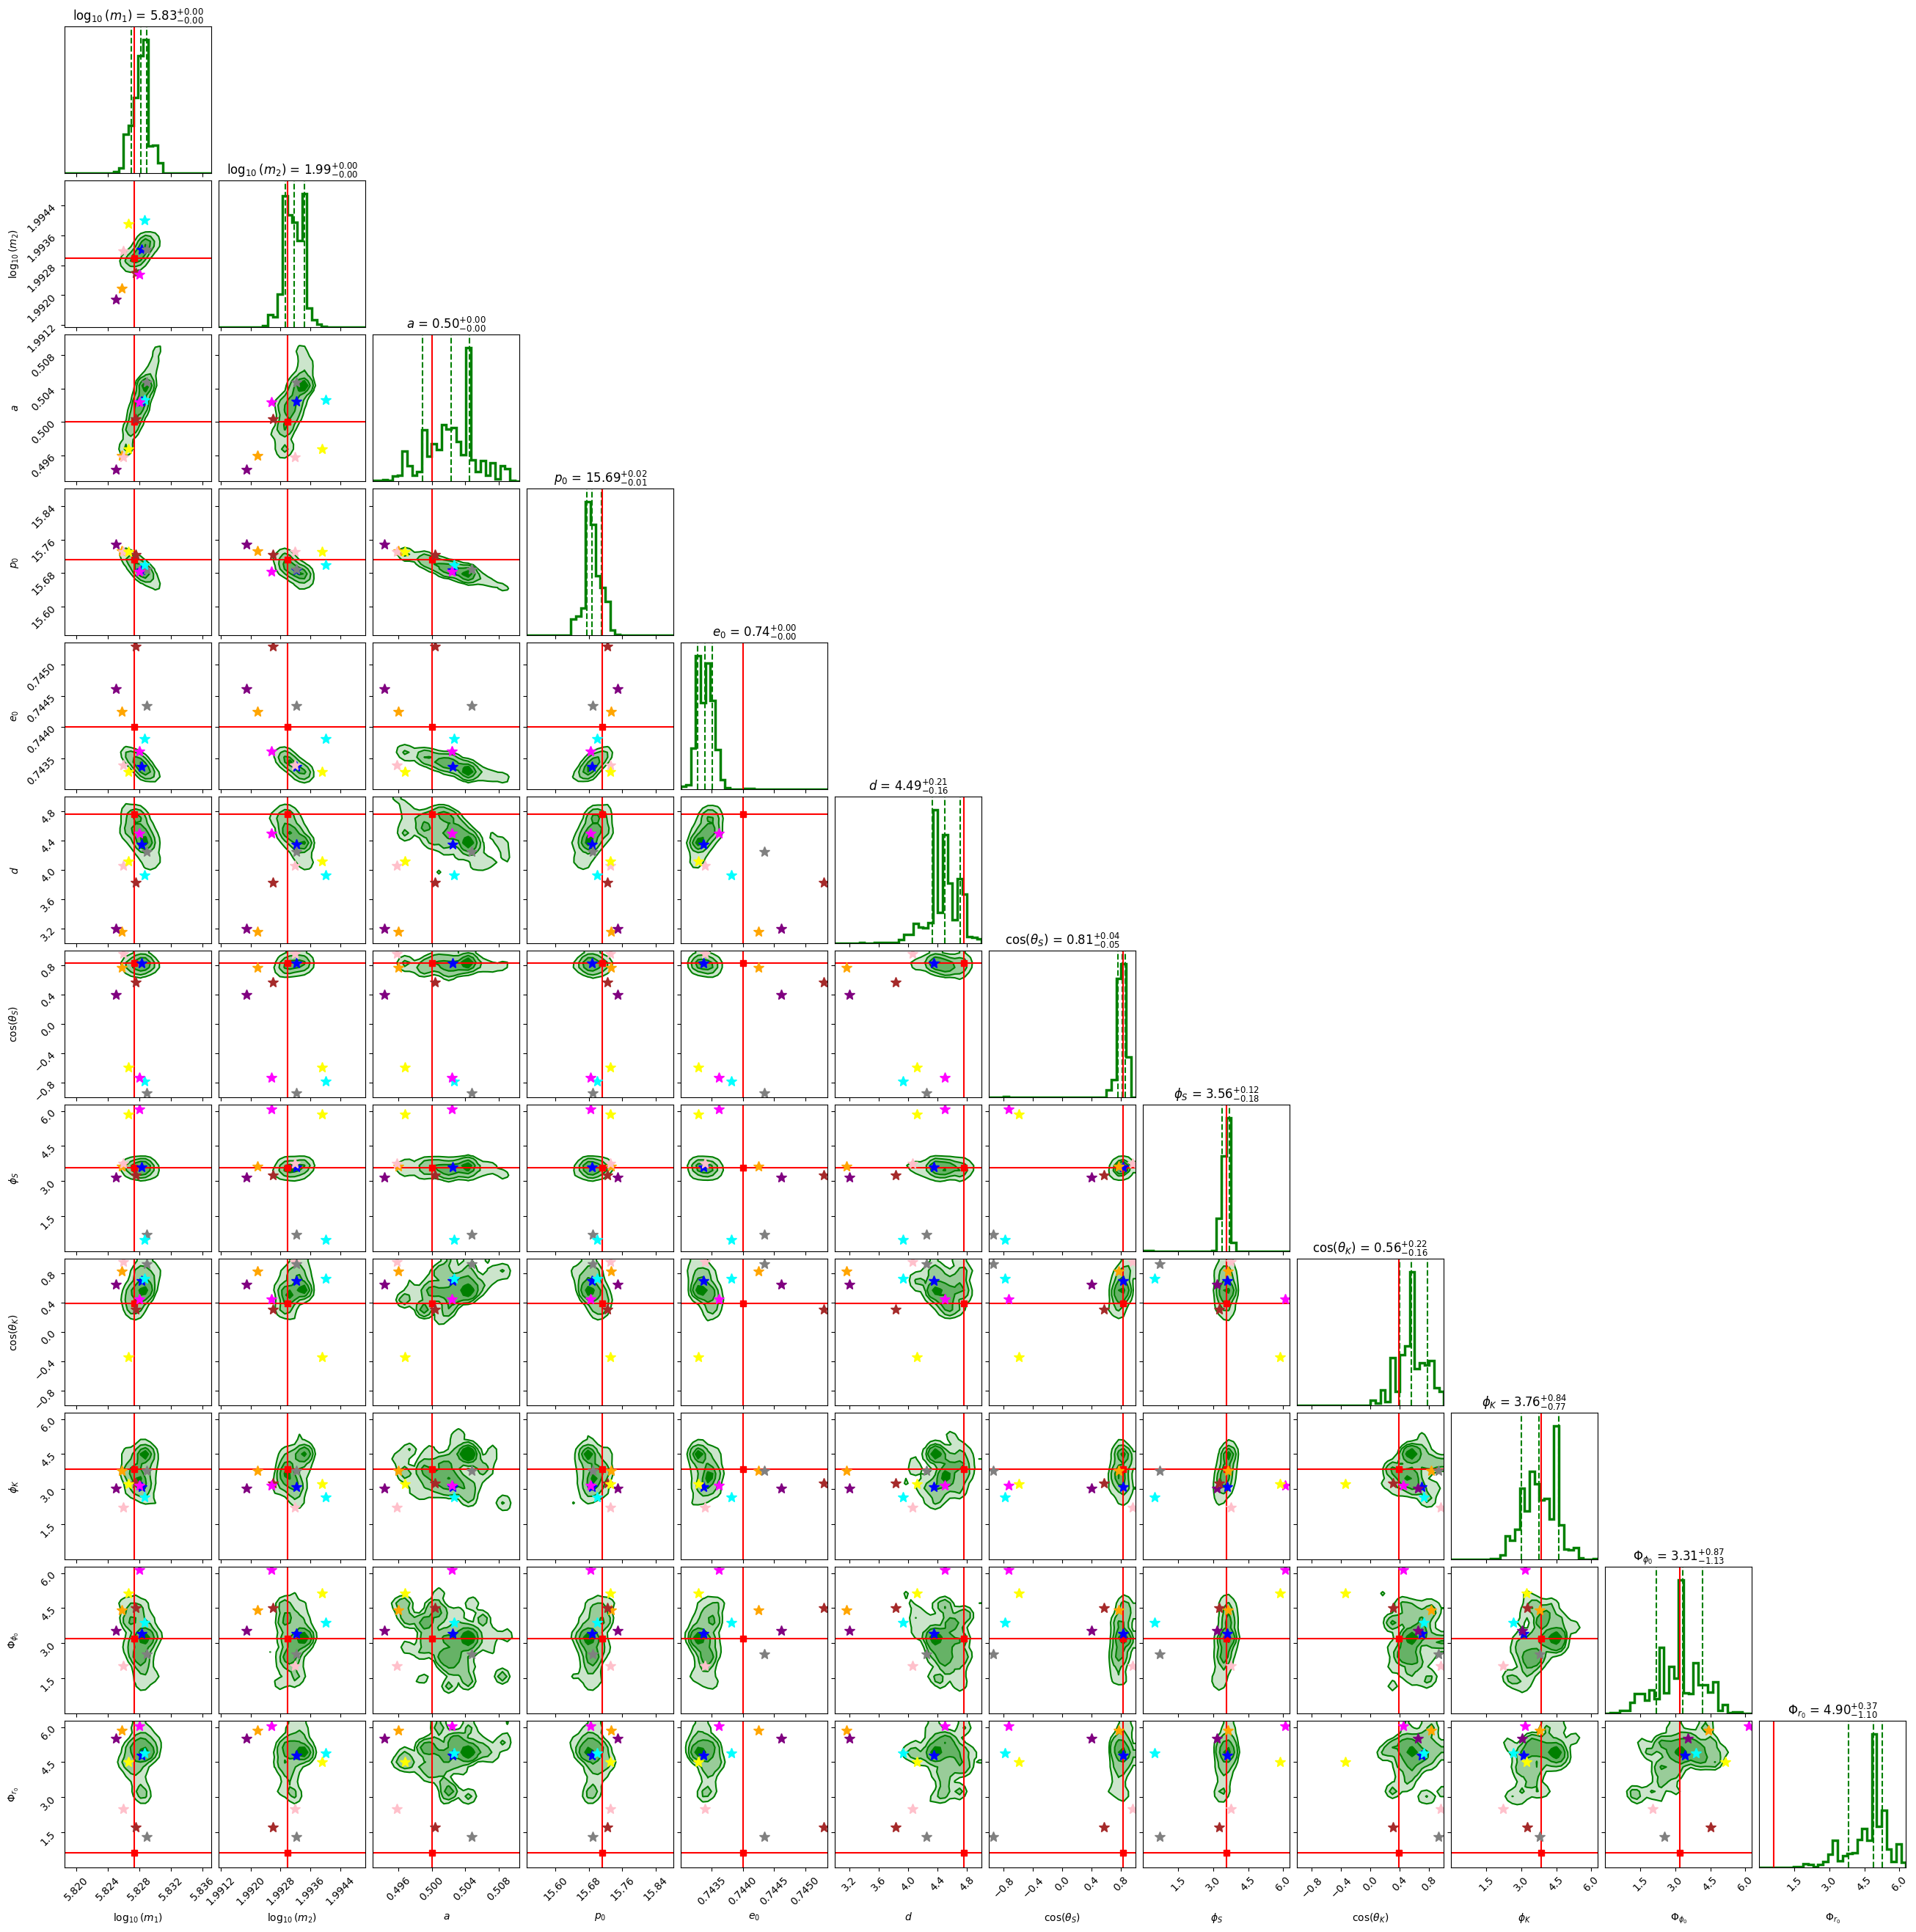

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$d$', r'$\cos(\theta_S)$', r'$\phi_S$', r'$\cos(\theta_K)$', r'$\phi_K$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1),
                       color='orange', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1),
                       color='purple', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1),
                       color='brown', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt5.reshape(1, -1),
                       color='pink', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt6.reshape(1, -1),
                       color='gray', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt7.reshape(1, -1),
                       color='cyan', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt8.reshape(1, -1),
                       color='magenta', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt9.reshape(1, -1),
                       color='yellow', marker='*', ms=10,
                       reverse=False)

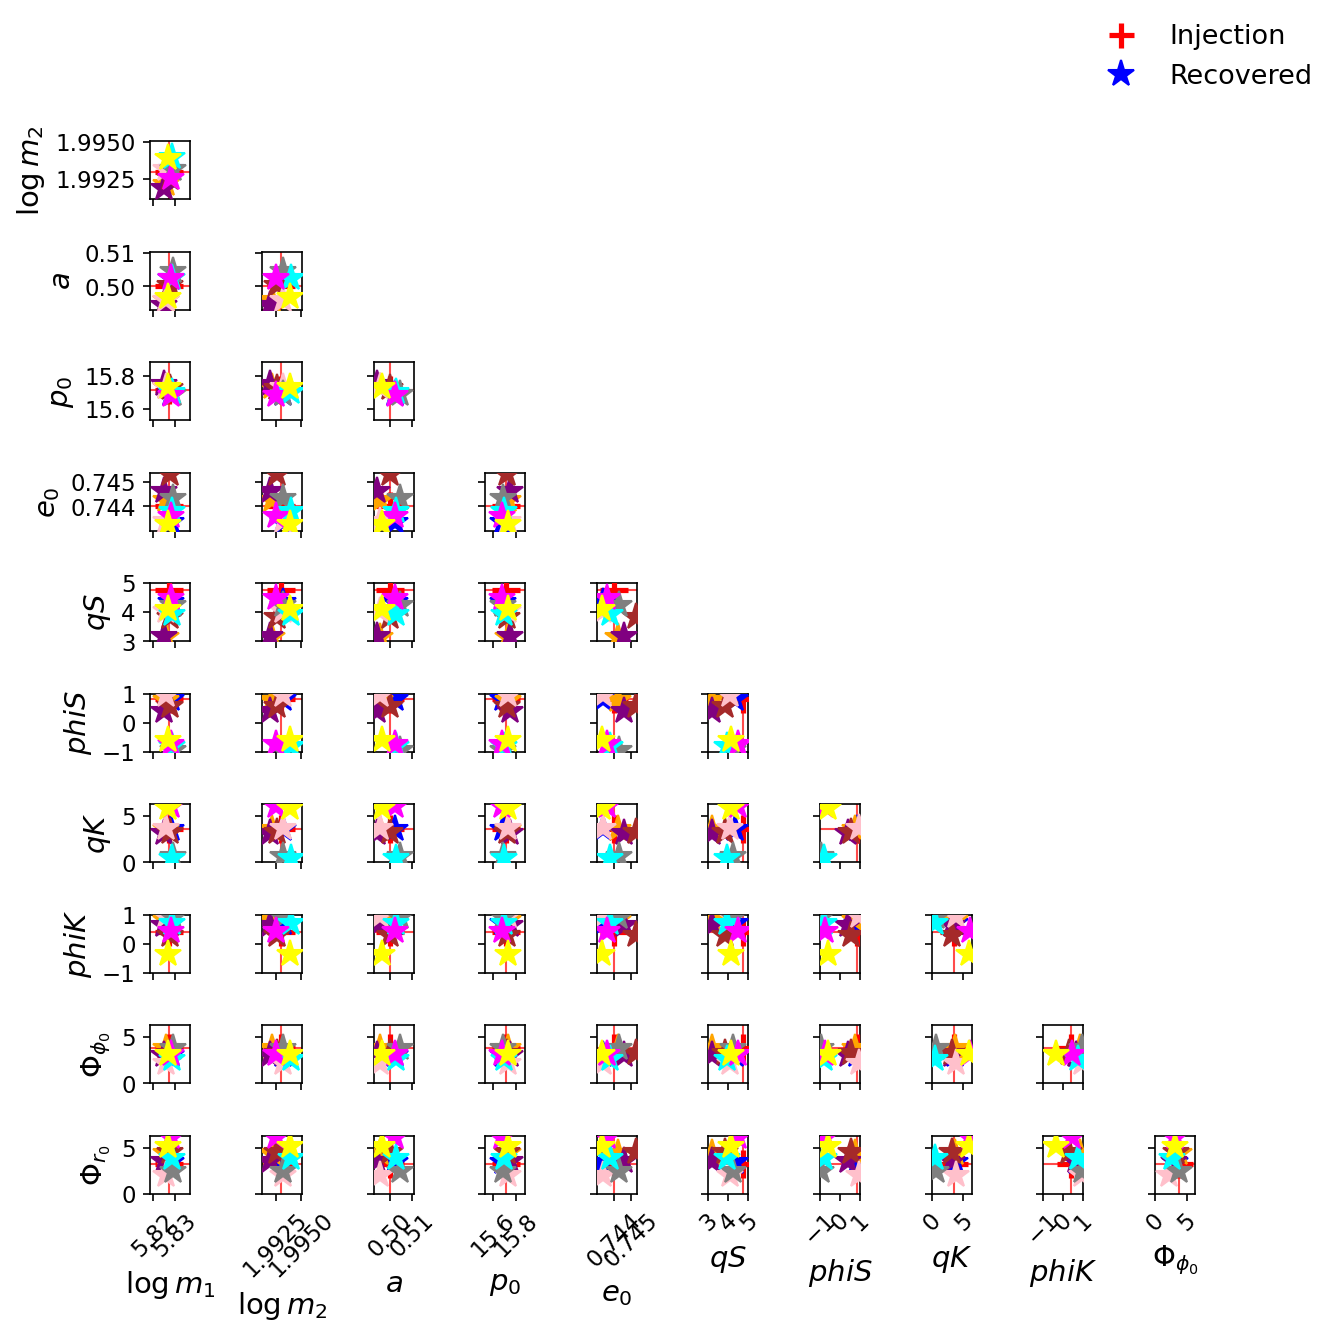

In [15]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$', r'$qK$', r'$phiK$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
maxld_pt3  = np.asarray(maxld_pt3).ravel()
maxld_pt4  = np.asarray(maxld_pt4).ravel()
maxld_pt5  = np.asarray(maxld_pt5).ravel()
maxld_pt6  = np.asarray(maxld_pt6).ravel()
maxld_pt7  = np.asarray(maxld_pt7).ravel()
maxld_pt8 = np.asarray(maxld_pt8).ravel()
maxld_pt9 = np.asarray(maxld_pt9).ravel()
# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        
        ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='purple',
                ms=13, zorder=4)
        
        ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='brown',
                ms=13, zorder=4)
        
        ax.plot(maxld_pt5[j], maxld_pt5[i], '*', color='pink',
                ms=13, zorder=4)

        ax.plot(maxld_pt6[j], maxld_pt6[i], '*', color='gray',
                ms=13, zorder=4)

        ax.plot(maxld_pt7[j], maxld_pt7[i], '*', color='cyan',
                ms=13, zorder=4)

        ax.plot(maxld_pt8[j], maxld_pt8[i], '*', color='magenta',
                ms=13, zorder=4)    

        ax.plot(maxld_pt9[j], maxld_pt9[i], '*', color='yellow',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [22]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82823584,  1.99321534,  0.50249727, 15.68750185,  0.74337348,
         4.34912446,  0.82592136,  3.60967665,  0.69796553,  3.09941436,
         3.40361281,  4.7843498 ]])

In [23]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [24]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


OutOfMemoryError: Out of memory allocating 60,750,000,128 bytes (allocated so far: 132,610,356,736 bytes).

In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [ ]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S12')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [29]:
# Bootstrap-resample the weighted posterior (same as paris3_lhs_s6_ext.py)
weights_norm = weights / weights.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples), size=50_000, replace=True, p=weights_norm)
cov_posterior = np.cov(samples[idx_rs].T)
sigma_diag = np.sqrt(np.diag(cov_posterior))

mu_center = maxld_pt1.ravel()          # max-log-density point (== mu_center in the script)
param_true_arr = np.asarray(param_true).ravel()

n_sigma_needed = (param_true_arr - mu_center) / sigma_diag

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'dist', 'cosqS', 'phiS', 'cosqK', 'phiK', 'Phi_phi0', 'Phi_r0']
for name, mu, sig, ns in zip(param_names, mu_center, sigma_diag, n_sigma_needed):
    print(f'{name:8s}: mu={mu:.5f}  sigma={sig:.5f}  true offset = {ns:+.2f} sigma')

print(f'\nMax |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): '
      f'{np.max(np.abs(n_sigma_needed)):.2f}')

logm1   : mu=5.82824  sigma=0.00104  true offset = -0.83 sigma
logm2   : mu=1.99322  sigma=0.00024  true offset = -0.90 sigma
a       : mu=0.50250  sigma=0.00300  true offset = -0.83 sigma
p0      : mu=15.68750  sigma=0.01965  true offset = +1.23 sigma
e0      : mu=0.74337  sigma=0.00013  true offset = +4.95 sigma
dist    : mu=4.34912  sigma=0.20328  true offset = +2.00 sigma
cosqS   : mu=0.82592  sigma=0.09813  true offset = +0.05 sigma
phiS    : mu=3.60968  sigma=0.22531  true offset = -0.13 sigma
cosqK   : mu=0.69797  sigma=0.19171  true offset = -1.61 sigma
phiK    : mu=3.09941  sigma=0.71903  true offset = +1.04 sigma
Phi_phi0: mu=3.40361  sigma=0.95947  true offset = -0.22 sigma
Phi_r0  : mu=4.78435  sigma=0.81747  true offset = -5.11 sigma

Max |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): 5.11


In [30]:
sigma_diag

array([1.04193934e-03, 2.43911300e-04, 3.00071614e-03, 1.96505196e-02,
       1.26598989e-04, 2.03275130e-01, 9.81301475e-02, 2.25308404e-01,
       1.91705382e-01, 7.19034664e-01, 9.59467907e-01, 8.17472535e-01])

In [38]:
# Prior bounds (same as paris3_lhs_s6_ext.py / stage1_anneal_s12 prior)
p1_lo = np.array([LOGM1_LIM[0], LOGM2_LIM[0], A_LIM[0], P0_LIM[0], E0_LIM[0], DIST_LIM[0], COSQS_LIM[0], PHIS_LIM[0], COSQK_LIM[0], PHIK_LIM[0], PHIPHI0_LIM[0], PHIR0_LIM[0]])
p1_hi = np.array([LOGM1_LIM[1], LOGM2_LIM[1], A_LIM[1], P0_LIM[1], E0_LIM[1], DIST_LIM[1], COSQS_LIM[1], PHIS_LIM[1], COSQK_LIM[1], PHIK_LIM[1], PHIPHI0_LIM[1], PHIR0_LIM[1]])

N_SIGMA = 6
print(f'N_SIGMA = {N_SIGMA:.0f}')

ellipse_lo = np.clip(mu_center - N_SIGMA * sigma_diag, p1_lo, p1_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA * sigma_diag, p1_lo, p1_hi)
box_width  = ellipse_hi - ellipse_lo
full_width = p1_hi - p1_lo

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'dist', 'cosqS', 'phiS', 'cosqK', 'phiK', 'Phi_phi0', 'Phi_r0']
for name, lo, hi, w, fw in zip(param_names, ellipse_lo, ellipse_hi, box_width, full_width):
    print(f'{name:8s}: [{lo:.5f}, {hi:.5f}]  width={w:.5f}  '
          f'({100*w/fw:.2f}% of full prior width)')

vol_frac = np.prod(box_width / full_width)
print(f'\nBox volume fraction of full prior box: {vol_frac:.3e}  (log10 = {np.log10(vol_frac):.2f})')


N_SIGMA = 6
logm1   : [5.82198, 5.83449]  width=0.01250  (67.26% of full prior width)
logm2   : [1.99175, 1.99468]  width=0.00293  (74.67% of full prior width)
a       : [0.49296, 0.51048]  width=0.01752  (100.00% of full prior width)
p0      : [15.56960, 15.80540]  width=0.23581  (67.05% of full prior width)
e0      : [0.74301, 0.74413]  width=0.00112  (47.79% of full prior width)
dist    : [3.12947, 5.00000]  width=1.87053  (93.53% of full prior width)
cosqS   : [0.23714, 1.00000]  width=0.76286  (38.14% of full prior width)
phiS    : [2.25783, 4.96153]  width=2.70370  (43.03% of full prior width)
cosqK   : [-0.45227, 1.00000]  width=1.45227  (72.61% of full prior width)
phiK    : [0.00000, 6.28319]  width=6.28319  (100.00% of full prior width)
Phi_phi0: [0.00000, 6.28319]  width=6.28319  (100.00% of full prior width)
Phi_r0  : [0.00000, 6.28319]  width=6.28319  (100.00% of full prior width)

Box volume fraction of full prior box: 1.794e-02  (log10 = -1.75)
